In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
import pandas as pd
from IPython.display import HTML
import time

from numcosmo_py import Nc, Ncm
from numcosmo_py.sky_match import (
    BestCandidates,
    Coordinates,
    DistanceMethod,
    SelectionCriteria,
    SkyMatch,
    SkyMatchResult,
)
from numcosmo_py.plotting.tools import set_rc_params_article, confidence_ellipse
set_rc_params_article(ncol=1)
Ncm.cfg_init()

Omega_b = 0.0486
Omega_c = 0.2614
Omega_k = 0.0
H0 = 67.7

#Omega_b = 0.05
#Omega_c = 0.25
#Omega_k = 0.0
#H0 = 70.0

# Create a cosmology object
cosmo = Nc.HICosmoDEXcdm.new()
cosmo.omega_x2omega_k()
cosmo["Omegab"] = Omega_b
cosmo["Omegac"] = Omega_c
cosmo["Omegak"] = Omega_k
cosmo["H0"] = H0
cosmo["w"] = -1.0

dist = Nc.Distance.new(100.0)
dist.compute_inv_comoving(True)
dist.prepare(cosmo)

# Lets fix the numpy seed to get reproducible results
np.random.seed(74682)

# Mocks construction

In [2]:
# Constants
CLUSTER_LENGTH = 100
HALO_LENGTH = 200

RA_MIN, RA_MAX = -10.0, 10.0
DEC_MIN, DEC_MAX = -10.0, 10.0
Z_MIN, Z_MAX = 0.2, 0.5
LOGM_MIN, LOGM_MAX = 13.0, 15.0  # Mass in log10 solar masses
LOGM_ADD_HALO_MIN, LOGM_ADD_HALO_MAX = 10.0, 13.0

# Generate cluster positions, redshifts, and masses
cluster_ra = np.random.uniform(RA_MIN, RA_MAX, CLUSTER_LENGTH)
cluster_sin_dec = np.random.uniform(
    np.sin(np.radians(DEC_MIN)), np.sin(np.radians(DEC_MAX)), CLUSTER_LENGTH
)
cluster_dec = np.degrees(np.arcsin(cluster_sin_dec))
cluster_z = np.random.uniform(Z_MIN, Z_MAX, CLUSTER_LENGTH)
cluster_logm = np.random.uniform(LOGM_MIN, LOGM_MAX, CLUSTER_LENGTH)
# Let's compute the cluster radii, and the 3D positions
cluster_r = np.array(dist.comoving_array(cosmo, cluster_z)) * cosmo.RH_Mpc()
cluster_x1 = (
    cluster_r * np.cos(np.radians(cluster_dec)) * np.cos(np.radians(cluster_ra))
)
cluster_x2 = (
    cluster_r * np.cos(np.radians(cluster_dec)) * np.sin(np.radians(cluster_ra))
)
cluster_x3 = cluster_r * np.sin(np.radians(cluster_dec))

# Generate halo positions, redshifts, and masses
# Lets first sample a halo < 5.0 Mpc from the cluster in each dimension
D_DIM = 5.0

halo_x1 = cluster_x1 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_x2 = cluster_x2 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_x3 = cluster_x3 + np.random.uniform(-D_DIM, D_DIM, CLUSTER_LENGTH)
halo_ra = np.degrees(np.arctan2(halo_x2, halo_x1))
halo_dec = np.degrees(np.arcsin(halo_x3 / cluster_r))
halo_r = np.sqrt(halo_x1**2 + halo_x2**2 + halo_x3**2)
halo_z = [dist.inv_comoving(cosmo, r / cosmo.RH_Mpc()) for r in halo_r]

# Now for the halo masses we use the cluster's masses added a Gaussian noise
halo_logm = cluster_logm + np.random.normal(0, 1.0, CLUSTER_LENGTH)

# Finally we add 100 more halos randomly
DELTA_OBJECTS = HALO_LENGTH - CLUSTER_LENGTH
halo_ra = np.append(halo_ra, np.random.uniform(RA_MIN, RA_MAX, DELTA_OBJECTS))
halo_dec = np.append(halo_dec, np.random.uniform(DEC_MIN, DEC_MAX, DELTA_OBJECTS))
halo_z = np.append(halo_z, np.random.uniform(Z_MIN, Z_MAX, DELTA_OBJECTS))
halo_logm = np.append(
    halo_logm, np.random.uniform(LOGM_ADD_HALO_MIN, LOGM_ADD_HALO_MAX, DELTA_OBJECTS)
)

/tmp/ipykernel_1147040/3772268390.py:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_1147040/3772268390.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("halos_clusters.pdf")
/tmp/ipykernel_1147040/3772268390.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("halos_clusters.pdf")
/global/u2/l/lettieri/miniforge3/envs/numcosmo_developer/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


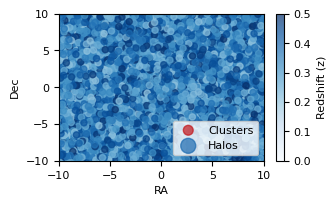

In [3]:
# Scale marker sizes with log mass
def scale_marker_size(log_mass, base_size=20, scale_factor=30):
    arr = scale_factor * (log_mass - LOGM_MIN)
    return base_size + np.where(arr < 0, 0, arr)


cluster_sizes = scale_marker_size(cluster_logm)
halo_sizes = scale_marker_size(halo_logm)

fig, ax = plt.subplots()

# Scatter plot for clusters (fixed red color)
ax.scatter(
    cluster_ra,
    cluster_dec,
    c=cluster_z,
    cmap="Reds",
    s=cluster_sizes,
    label="Clusters",
    alpha=0.7,
    vmin=0.0,
)

# Scatter plot for halos (color varies with z, from light to dark blue)
halo_scatter = ax.scatter(
    halo_ra,
    halo_dec,
    c=halo_z,
    cmap="Blues",
    s=halo_sizes,
    label="Halos",
    alpha=0.7,
    vmin=0.0,
)

# Colorbar to indicate redshift values
color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_xlim(RA_MIN, RA_MAX)
ax.set_ylim(DEC_MIN, DEC_MAX)
ax.legend()
plt.tight_layout()
plt.savefig("halos_clusters.pdf")
#plt.show()

In [4]:
# Create the astropy table for clusters
clusters = Table(
    [cluster_ra, cluster_dec, cluster_z, cluster_logm],
    names=["cluster_RA", "cluster_DEC", "cluster_z", "cluster_logM"],
)

# Create the astropy table for halos
halos = Table(
    [halo_ra, halo_dec, halo_z, halo_logm],
    names=["halo_RA", "halo_DEC", "halo_z", "halo_logM"],
)

# Create the Coordinates object for clusters
cluster_coords = Coordinates(RA="cluster_RA", DEC="cluster_DEC", z="cluster_z")

# Create the Coordinates object for halos
halo_coords = Coordinates(RA="halo_RA", DEC="halo_DEC", z="halo_z")

def show_pandas(df: pd.DataFrame):
    return HTML(df.to_html(float_format="%.2f", max_rows=10))


show_pandas(clusters.to_pandas())

,cluster_RA,cluster_DEC,cluster_z,cluster_logM
0,-5.65,3.07,0.39,13.02
1,6.51,2.55,0.37,14.41
2,7.07,6.80,0.43,13.30
3,4.02,3.10,0.43,13.78
4,8.27,-4.83,0.39,14.90
...,...,...,...,...
999995,-3.58,-0.61,0.44,13.99
999996,5.64,-6.94,0.40,13.68
999997,8.29,8.80,0.38,14.78
999998,3.94,-1.63,0.39,14.10


In [5]:
show_pandas(halos.to_pandas())

,halo_RA,halo_DEC,halo_z,halo_logM
0,-5.62,3.09,0.39,12.70
1,6.42,2.61,0.37,14.00
2,7.05,6.66,0.43,12.95
3,3.85,3.06,0.43,15.46
4,8.19,-4.97,0.39,16.16
...,...,...,...,...
1999995,9.18,-9.79,0.37,10.70
1999996,3.17,0.09,0.23,12.92
1999997,2.88,-0.02,0.25,12.07
1999998,1.76,3.97,0.22,11.97


# 3D matching

In [6]:
# Create the SkyMatch object
sm = SkyMatch(clusters, cluster_coords, halos, halo_coords)

## Multiple Match

In [7]:
# Perform 3D matching
# We are keeping the number of nearest neighbors to 6
result = sm.match_3d(cosmo, n_nearest_neighbours=6)

def convert_table_multi_column(table):
    table["Index_matched"] = [np.array2string(i) for i in table["Index_matched"]]
    table["RA_matched"] = [
        np.array2string(ra, precision=2) for ra in table["RA_matched"]
    ]
    table["DEC_matched"] = [
        np.array2string(dec, precision=2) for dec in table["DEC_matched"]
    ]
    if "distances" in table.columns:
        table["distances"] = [
            np.array2string(dist, precision=2) for dist in table["distances"]
        ]
    table["z_matched"] = [np.array2string(z, precision=2) for z in table["z_matched"]]

    return table


show_pandas(convert_table_multi_column(result.to_table_complete()).to_pandas())

,Index,RA,DEC,z,Index_matched,distances,RA_matched,DEC_matched,z_matched
0,0,-5.65,3.07,0.39,[1374343 1359496 769702 0 764650 1949430],[1.81 1.88 2.47 2.55 2.62 2.68],[-5.72 -5.64 -5.6 -5.62 -5.64 -5.71],[3.01 2.97 2.96 3.09 2.96 3.19],[0.39 0.39 0.39 0.39 0.39 0.39]
1,1,6.51,2.55,0.37,[1636251 1 594942 669035 305691 1033640],[2.09 2.24 3.66 4. 4.13 4.26],[6.53 6.42 6.63 6.31 6.57 6.66],[2.52 2.61 2.44 2.55 2.43 2.39],[0.37 0.37 0.37 0.37 0.37 0.37]
2,2,7.07,6.80,0.43,[ 429246 1126716 318936 1147012 2 870737],[1.59 1.87 2.91 2.97 3.04 3.1 ],[7.03 6.99 7.05 6.99 7.05 7.11],[6.75 6.76 6.87 6.91 6.66 6.93],[0.43 0.43 0.43 0.43 0.43 0.43]
3,3,4.02,3.10,0.43,[ 323078 948434 1722423 1248200 3 1356614],[2.28 2.72 2.78 3.57 3.62 3.8 ],[4.02 3.92 3.92 3.9 3.85 4. ],[3.21 3.07 3.13 3.03 3.06 3.02],[0.43 0.43 0.43 0.43 0.43 0.43]
4,4,8.27,-4.83,0.39,[1673612 1147041 258174 630764 1620651 977467],[1.58 1.9 1.97 2.56 2.58 2.8 ],[8.26 8.2 8.23 8.36 8.31 8.26],[-4.79 -4.9 -4.92 -4.89 -4.8 -4.83],[0.39 0.39 0.39 0.39 0.4 0.39]
...,...,...,...,...,...,...,...,...,...
999995,999995,-3.58,-0.61,0.44,[1231485 999995 1658786 840518 168209 243961],[1.07 2.02 2.62 2.76 3.53 3.59],[-3.62 -3.54 -3.54 -3.71 -3.59 -3.54],[-0.58 -0.65 -0.64 -0.65 -0.78 -0.78],[0.44 0.44 0.44 0.44 0.44 0.44]
999996,999996,5.64,-6.94,0.40,[ 246743 1068256 1571719 948701 1294408 31761],[0.54 2.37 2.9 3.25 3.75 3.84],[5.65 5.6 5.55 5.79 5.48 5.58],[-6.91 -7.04 -7.01 -6.89 -6.97 -7.07],[0.4 0.4 0.4 0.4 0.4 0.4]
999997,999997,8.29,8.80,0.38,[ 793485 560466 492306 1834766 1253158 1152299],[1.83 2.53 2.63 2.92 3.15 3.55],[8.21 8.21 8.35 8.4 8.32 8.31],[8.83 8.83 8.71 8.86 8.64 8.63],[0.38 0.38 0.38 0.38 0.38 0.38]
999998,999998,3.94,-1.63,0.39,[ 737217 999998 781659 224416 1781283 1251905],[1.8 3.14 3.27 4.11 4.43 4.52],[3.94 4.03 3.91 4.06 4.1 4.02],[-1.68 -1.52 -1.78 -1.77 -1.77 -1.84],[0.4 0.4 0.39 0.4 0.4 0.39]


In [8]:
# Filter the results to keep only those with a distance less than 60 Mpc
mask = result.filter_mask_by_distance(60.0)

show_pandas(convert_table_multi_column(result.to_table_complete(mask=mask)).to_pandas())

,Index,RA,DEC,z,Index_matched,distances,RA_matched,DEC_matched,z_matched
0,0,-5.65,3.07,0.39,[1374343 1359496 769702 0 764650 1949430],[1.81 1.88 2.47 2.55 2.62 2.68],[-5.72 -5.64 -5.6 -5.62 -5.64 -5.71],[3.01 2.97 2.96 3.09 2.96 3.19],[0.39 0.39 0.39 0.39 0.39 0.39]
1,1,6.51,2.55,0.37,[1636251 1 594942 669035 305691 1033640],[2.09 2.24 3.66 4. 4.13 4.26],[6.53 6.42 6.63 6.31 6.57 6.66],[2.52 2.61 2.44 2.55 2.43 2.39],[0.37 0.37 0.37 0.37 0.37 0.37]
2,2,7.07,6.80,0.43,[ 429246 1126716 318936 1147012 2 870737],[1.59 1.87 2.91 2.97 3.04 3.1 ],[7.03 6.99 7.05 6.99 7.05 7.11],[6.75 6.76 6.87 6.91 6.66 6.93],[0.43 0.43 0.43 0.43 0.43 0.43]
3,3,4.02,3.10,0.43,[ 323078 948434 1722423 1248200 3 1356614],[2.28 2.72 2.78 3.57 3.62 3.8 ],[4.02 3.92 3.92 3.9 3.85 4. ],[3.21 3.07 3.13 3.03 3.06 3.02],[0.43 0.43 0.43 0.43 0.43 0.43]
4,4,8.27,-4.83,0.39,[1673612 1147041 258174 630764 1620651 977467],[1.58 1.9 1.97 2.56 2.58 2.8 ],[8.26 8.2 8.23 8.36 8.31 8.26],[-4.79 -4.9 -4.92 -4.89 -4.8 -4.83],[0.39 0.39 0.39 0.39 0.4 0.39]
...,...,...,...,...,...,...,...,...,...
999995,999995,-3.58,-0.61,0.44,[1231485 999995 1658786 840518 168209 243961],[1.07 2.02 2.62 2.76 3.53 3.59],[-3.62 -3.54 -3.54 -3.71 -3.59 -3.54],[-0.58 -0.65 -0.64 -0.65 -0.78 -0.78],[0.44 0.44 0.44 0.44 0.44 0.44]
999996,999996,5.64,-6.94,0.40,[ 246743 1068256 1571719 948701 1294408 31761],[0.54 2.37 2.9 3.25 3.75 3.84],[5.65 5.6 5.55 5.79 5.48 5.58],[-6.91 -7.04 -7.01 -6.89 -6.97 -7.07],[0.4 0.4 0.4 0.4 0.4 0.4]
999997,999997,8.29,8.80,0.38,[ 793485 560466 492306 1834766 1253158 1152299],[1.83 2.53 2.63 2.92 3.15 3.55],[8.21 8.21 8.35 8.4 8.32 8.31],[8.83 8.83 8.71 8.86 8.64 8.63],[0.38 0.38 0.38 0.38 0.38 0.38]
999998,999998,3.94,-1.63,0.39,[ 737217 999998 781659 224416 1781283 1251905],[1.8 3.14 3.27 4.11 4.43 4.52],[3.94 4.03 3.91 4.06 4.1 4.02],[-1.68 -1.52 -1.78 -1.77 -1.77 -1.84],[0.4 0.4 0.39 0.4 0.4 0.39]


In [9]:
# Plot the filtered results


cluster_sizes = scale_marker_size(cluster_logm)
halo_sizes = scale_marker_size(halo_logm)


def plot_mask(mask):
    fig, ax = plt.subplots()

    # Scatter plot for clusters (fixed red color)
    ax.scatter(
        cluster_ra,
        cluster_dec,
        c=cluster_z,
        cmap="Reds",
        s=cluster_sizes,
        label="Clusters",
        alpha=0.7,
        vmin=0.0,
    )

    # Scatter plot for halos (color varies with z, from light to dark blue)
    halo_scatter = ax.scatter(
        halo_ra,
        halo_dec,
        c=halo_z,
        cmap="Blues",
        s=halo_sizes,
        label="Halos",
        alpha=0.7,
        vmin=0.0,
    )

    # Now we iterate over the filtered results plotting a line connecting the cluster to all matched halos
    for i, (idx, m) in enumerate(zip(result.nearest_neighbours_indices, mask.array)):
        for halo_i in idx[m]:
            ax.plot(
                [cluster_ra[i], halo_ra[halo_i]],
                [cluster_dec[i], halo_dec[halo_i]],
                color="black",
                alpha=0.5,
            )

    ax.legend()

    # Colorbar to indicate redshift values
    color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")

    return fig


#plot_mask(mask)
#plt.show()

## Best Match

In [10]:
# Perform best match
best = result.select_best(mask=mask, selection_criteria=SelectionCriteria.DISTANCES)

show_pandas(convert_table_multi_column(result.to_table_best(best)).to_pandas())

,Index,RA,DEC,z,Index_matched,RA_matched,DEC_matched,z_matched
0,0,-5.65,3.07,0.39,1374343,-5.72,3.01,0.39
1,1,6.51,2.55,0.37,1636251,6.53,2.52,0.37
2,2,7.07,6.80,0.43,429246,7.03,6.75,0.43
3,3,4.02,3.10,0.43,323078,4.02,3.21,0.43
4,4,8.27,-4.83,0.39,1673612,8.26,-4.79,0.39
...,...,...,...,...,...,...,...,...
999995,999995,-3.58,-0.61,0.44,1231485,-3.62,-0.58,0.44
999996,999996,5.64,-6.94,0.40,246743,5.65,-6.91,0.4
999997,999997,8.29,8.80,0.38,793485,8.21,8.83,0.38
999998,999998,3.94,-1.63,0.39,737217,3.94,-1.68,0.4


In [11]:
# Plot the best matches


def plot_best(best):
    fig, ax = plt.subplots()

    # Scatter plot for clusters (fixed red color)
    ax.scatter(
        cluster_ra,
        cluster_dec,
        c=cluster_z,
        cmap="Reds",
        s=cluster_sizes,
        label="Clusters",
        alpha=0.7,
        vmin=0.0,
    )

    # Scatter plot for halos (color varies with z, from light to dark blue)
    halo_scatter = ax.scatter(
        halo_ra,
        halo_dec,
        c=halo_z,
        cmap="Blues",
        s=halo_sizes,
        label="Halos",
        alpha=0.7,
        vmin=0.0,
    )

    # Now we iterate over the best matches plotting a line connecting the cluster to the best halos
    for cluster_i, halo_i in zip(best.query_indices, best.indices):
        ax.plot(
            [cluster_ra[cluster_i], halo_ra[halo_i]],
            [cluster_dec[cluster_i], halo_dec[halo_i]],
            color="black",
            alpha=0.5,
        )

    ax.legend()

    # Colorbar to indicate redshift values
    color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    plt.tight_layout()
    return fig


#plot_best(best)
#plt.show()  

## Cross Match

In [12]:
# Perform cross match

cross = sm.invert_query_match()

cross_result = cross.match_3d(cosmo, n_nearest_neighbours=6)
cross_mask = cross_result.filter_mask_by_distance(60.0)

cross_best = cross_result.select_best(mask=cross_mask, selection_criteria=SelectionCriteria.DISTANCES)

cross_match = best.get_cross_match_indices(cross_best)

# Plot the cross matches


def plot_cross(cross_match):
    fig, ax = plt.subplots()

    # Scatter plot for clusters (fixed red color)
    ax.scatter(
        cluster_ra,
        cluster_dec,
        c=cluster_z,
        cmap="Reds",
        s=cluster_sizes,
        label="Clusters",
        alpha=0.7,
        vmin=0.0,
    )

    # Scatter plot for halos (color varies with z, from light to dark blue)
    halo_scatter = ax.scatter(
        halo_ra,
        halo_dec,
        c=halo_z,
        cmap="Blues",
        s=halo_sizes,
        label="Halos",
        alpha=0.7,
        vmin=0.0,
    )

    # Now we iterate over the cross matches plotting a line connecting the cluster to the best halos
    for cluster_i, halo_i in cross_match.items():
        ax.plot(
            [cluster_ra[cluster_i], halo_ra[halo_i]],
            [cluster_dec[cluster_i], halo_dec[halo_i]],
            color="black",
            alpha=0.5,
        )

    ax.legend()

    # Colorbar to indicate redshift values
    color_bar = plt.colorbar(halo_scatter, ax=ax, label="Redshift (z)")

    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    plt.tight_layout()
    return fig


#plot_cross(cross_match)
#plt.show()

# 2D Matching

## Multiple Match

In [13]:
# Perform 2D matching  
# Keeping the number of nearest neighbors to 6 
start_m = time.perf_counter()
result = sm.match_2d(
    cosmo, n_nearest_neighbours=6, distance_method=DistanceMethod.QUERY_RADIUS
)
end_m = time.perf_counter()

time_m = end_m - start_m

print(f"Execution time: {time_m:.6f} seconds")


#show_pandas(convert_table_multi_column(result.to_table_complete()).to_pandas())

Execution time: 38.572286 seconds


In [14]:
# Apply a distance filter to retain only matches within 60 Mpc
mask = result.filter_mask_by_distance(60.0)

# Further refine by keeping only matches with redshift < 0.02
mask = result.filter_mask_by_redshift_proximity(0.02, mask=mask)
show_pandas(convert_table_multi_column(result.to_table_complete(mask)).to_pandas())

,Index,RA,DEC,z,Index_matched,distances,RA_matched,DEC_matched,z_matched
0,0,-5.65,3.07,0.39,[1441813 1706903],[0.04 0.44],[-5.65 -5.63],[3.07 3.08],[0.44 0.4 ]
1,1,6.51,2.55,0.37,[1455284],[0.39],[6.53],[2.56],[0.33]
2,2,7.07,6.80,0.43,[1344909 85032 504759],[0.21 0.28 0.34],[7.06 7.06 7.05],[6.81 6.8 6.8 ],[0.48 0.46 0.4 ]
3,3,4.02,3.10,0.43,[],[],[],[],[]
4,4,8.27,-4.83,0.39,[ 977467 671183 1614452 1425562 155787],[0.21 0.29 0.39 0.52 0.52],[8.26 8.26 8.27 8.27 8.29],[-4.83 -4.82 -4.85 -4.8 -4.81],[0.39 0.39 0.39 0.44 0.35]
...,...,...,...,...,...,...,...,...,...
999995,999995,-3.58,-0.61,0.44,[921795],[0.44],[-3.57],[-0.6],[0.46]
999996,999996,5.64,-6.94,0.40,[ 803795 77661 1006539 246743],[0.36 0.36 0.45 0.46],[5.65 5.64 5.66 5.65],[-6.95 -6.95 -6.92 -6.91],[0.41 0.37 0.45 0.4 ]
999997,999997,8.29,8.80,0.38,[],[],[],[],[]
999998,999998,3.94,-1.63,0.39,[1682208 856471 921515],[0.11 0.19 0.21],[3.93 3.94 3.93],[-1.62 -1.64 -1.64],[0.35 0.42 0.42]


In [15]:
#plot_mask(mask)
#plt.tight_layout()
#plt.savefig("multipe_match_proximity.pdf")
#plt.show()

## Best Match

In [16]:
# Find the best match for each cluster

start_b = time.perf_counter()
best = result.select_best(
    selection_criteria=SelectionCriteria.MORE_MASSIVE,
    mask=mask,
    more_massive_column="halo_logM",
)
end_b = time.perf_counter()

time_b = end_b - start_b
print(f"Execution time: {time_b:.6f} seconds")



show_pandas(
    convert_table_multi_column(
        result.to_table_best(
            best,
            query_properties={"cluster_logM": "cluster_logM"},
            match_properties={"halo_logM": "halo_logM"},
        )
    ).to_pandas()
)

Execution time: 18.734619 seconds


,Index,RA,DEC,z,Index_matched,RA_matched,DEC_matched,z_matched,cluster_logM,halo_logM
0,0,-5.65,3.07,0.39,1441813,-5.65,3.07,0.44,13.02,11.25
1,1,6.51,2.55,0.37,1455284,6.53,2.56,0.33,14.41,12.46
2,2,7.07,6.80,0.43,504759,7.05,6.8,0.4,13.30,13.88
3,4,8.27,-4.83,0.39,155787,8.29,-4.81,0.35,14.90,15.04
4,5,-3.24,-5.30,0.30,1743798,-3.25,-5.3,0.31,13.40,10.24
...,...,...,...,...,...,...,...,...,...,...
897061,999993,-4.17,6.83,0.24,34089,-4.17,6.85,0.23,13.64,14.86
897062,999994,-2.15,-3.29,0.39,430753,-2.16,-3.3,0.34,13.78,12.51
897063,999995,-3.58,-0.61,0.44,921795,-3.57,-0.6,0.46,13.99,15.57
897064,999996,5.64,-6.94,0.40,246743,5.65,-6.91,0.4,13.68,14.30


In [17]:
#plot_best(best)
#plt.savefig("best_match_proximity.pdf")
#plt.show()

## Cross Match

In [18]:
# Find the best match for each halo





cross = sm.invert_query_match()

start_c = time.perf_counter()

cross_result = cross.match_2d(cosmo, n_nearest_neighbours=6)

cross_mask = cross_result.filter_mask_by_distance(60.0)
cross_mask = cross_result.filter_mask_by_redshift_proximity(0.02, mask=cross_mask)

cross_best = cross_result.select_best(
    selection_criteria=SelectionCriteria.REDSHIFT_PROXIMITY, mask=cross_mask
)


cross_match = best.get_cross_match_indices(cross_best)

end_c = time.perf_counter()

time_c = end_c - start_c

print(f"Execution time: {time_c:.6f} seconds")

show_pandas(
    convert_table_multi_column(
        cross_result.to_table_best(
            cross_best,
            query_properties={"halo_logM": "halo_logM"},
            match_properties={"cluster_logM": "cluster_logM"},
        )
    ).to_pandas()
)

Execution time: 210.682118 seconds


,Index,RA,DEC,z,Index_matched,RA_matched,DEC_matched,z_matched,halo_logM,cluster_logM
0,0,-5.62,3.09,0.39,335310,-5.63,3.1,0.41,12.70,14.71
1,1,6.42,2.61,0.37,374659,6.41,2.63,0.38,14.00,14.59
2,2,7.05,6.66,0.43,22048,7.07,6.66,0.49,12.95,14.82
3,3,3.85,3.06,0.43,201439,3.87,3.07,0.43,15.46,14.35
4,4,8.19,-4.97,0.39,118394,8.2,-4.98,0.39,16.16,13.14
...,...,...,...,...,...,...,...,...,...,...
1794909,1999992,7.46,-0.84,0.34,295624,7.43,-0.84,0.32,12.49,13.54
1794910,1999995,9.18,-9.79,0.37,206654,9.15,-9.79,0.35,10.70,14.96
1794911,1999997,2.88,-0.02,0.25,439394,2.86,0.,0.24,12.07,14.23
1794912,1999998,1.76,3.97,0.22,526220,1.77,3.97,0.23,11.97,13.52


In [19]:
#plot_cross(cross_match)
#plt.tight_layout()
#plt.savefig("cross_match_proximity.pdf")
#plt.show()

In [20]:
# Convert dictionary to DataFrame for better visualization
cross_match_df = pd.DataFrame(
    list(cross_match.items()), columns=["Cluster ID", "Matched Halo ID"]
)

# Compute correctness
wrong = cross_match_df["Cluster ID"] != cross_match_df["Matched Halo ID"]
right = ~wrong  # Logical NOT for correct matches

# Add correctness column
cross_match_df["Correct Match"] = right

cross_match_df

,Cluster ID,Matched Halo ID,Correct Match
0,5,1743798,False
1,8,569578,False
2,11,11,True
3,13,1709442,False
4,15,942837,False
...,...,...,...
393520,999989,764529,False
393521,999992,393749,False
393522,999993,34089,False
393523,999994,430753,False


In [21]:
# Display match statistics
HTML(
    pd.DataFrame(
        {
            "Total Matches": [len(cross_match)],
            "Correct Matches": [right.sum()],
            "Wrong Matches": [wrong.sum()],
        }
    ).to_html(index=False)
)

Total Matches,Correct Matches,Wrong Matches
393525,4767,388758


In [22]:
print(time_m)
print(time_b)
print(time_c)
print(time_m+time_b+time_c)

38.57228561397642
18.734618612914346
210.68211786600295
267.9890220928937


In [23]:
#time for each run 2D seconds


#100,200 = 0.146889 multiple +  0.000385 best + 0.168425 cross = 0,315699 seconds, 66/68(100)
#1000, 2000 = 0.155581 multiple + 0.04131448804400861 best + 0.382348 cross =  0.5804, 616/635(1000)
#10000, 20000 = 0.26347 multiple + 0.173033 best + 1.86618 cross =  2.30269, 4117/5061(10000)
#100000, 200000 =  1.4917 multiple + 2.14627 best + 17.979508 cross = 21.617507, 4761/39562(100000)
#1000000, 2000000 = 38.57229 multiple + 18.7347 best + 17.979508 cross = 267.9890, 4767/393525(1000000)